In [1]:
import numpy as np
from sklearn.metrics import classification_report
from tstim.cluster import TSTIM

In [2]:
def predict(self, data, num_clusters):
    """
    Predict the cluster label of each series.

    :param data: term frequency time series data
    :param num_clusters: determined by Elbow-Method
    :return: predicted cluster label
    """

    y_pred = show_kmeans(data, self.feature, num_clusters)
    return y_pred

In [3]:
def extract_clusters_by_labels(time_series, labels, num_clusters):
    """
    Extract time series data for each cluster.

    :param time_series: Original time series data (numpy array)
    :param labels: Cluster labels for each time series (numpy array)
    :param num_clusters: Number of clusters
    :return: Dictionary of time series for each cluster
    """
    clusters = {i: [] for i in range(num_clusters)}

    for idx, label in enumerate(labels):
        clusters[label].append(time_series[idx])

    return clusters

In [4]:
LABEL_DICT = {
        0: 'Normal',
        1: 'Cyclic',
        2: 'Increasing trend',
        3: 'Decreasing trend',
        4: 'Upward shift',
        5: 'Downward shift'
}
LABEL_to_ID = {v: k for k, v in LABEL_DICT.items()}

with open('/yy/TFSC/data/MetaL_m_Series.txt', 'r') as file:
    content = file.read().strip().split('\n')

Y = []
for i in range(6):
    Y += [i] * 100

data = []
for c in content:
    c = ','.join([i for i in c.split(' ') if i])
    item = eval(f'[{c}]')

    data.append(item)

data = np.array(data)

2025-04-15 06:39:51 [INFO] TS-TIM parameters: 
|Device: cpu | SIGMA: 7 | EIGVEC_NUM: 6 | RANDOM_SEED: 0 | KMAX: 15|

2025-04-15 06:39:51 [INFO] Min-Max Normalization...
2025-04-15 06:39:51 [INFO] DTW Calculation...
2025-04-15 06:39:51 [INFO] func get_dtw_dist cost time:0.18170499 s
2025-04-15 06:39:51 [INFO] Local Scaling Gaussian Kernel Normalization...
2025-04-15 06:39:54 [INFO] Laplacian Normalization...
2025-04-15 06:39:54 [INFO] func normalized_laplacian cost time:0.00028796 s
2025-04-15 06:39:54 [INFO] SVD Calculation...
2025-04-15 06:39:54 [INFO] Elbow-Method...
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4

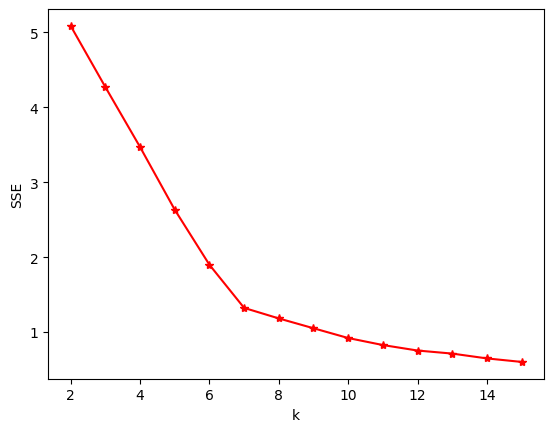

In [5]:
tstim_model = TSTIM(
        sigma=7,
        eigvec_num=6,
        random_seed=0,
        k_max=15
)

v = tstim_model.pipline(data)

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
100%|█████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 13.99it/s]


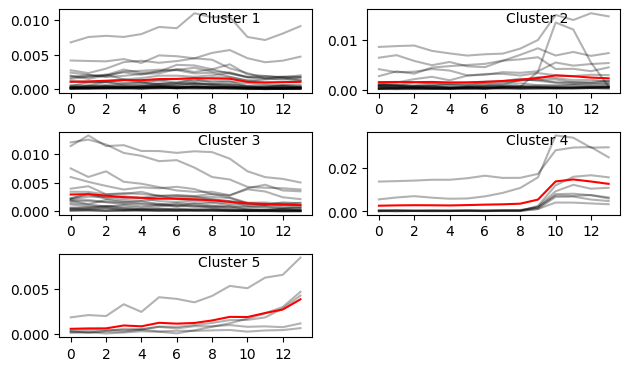

In [10]:
y_pred = tstim_model.predict(data, num_clusters=5)

In [11]:
clusters = extract_clusters_by_labels(data, y_pred, num_clusters=5)

for cluster_id, time_series_list in clusters.items():
    print(f"Cluster {cluster_id}: {len(time_series_list)} time series")

Cluster 0: 27 time series
Cluster 1: 21 time series
Cluster 2: 21 time series
Cluster 3: 8 time series
Cluster 4: 5 time series


In [12]:
clusters = {k: [arr.tolist() for arr in v] for k, v in clusters.items()}

In [15]:
import json
def find_cluster_word(cluster_id):
    with open('/yy/TFSC/data/relative_freq.json','r',encoding='utf-8') as f:
        word_times=json.load(f)
    word_set=set()
    for slice_times in clusters[cluster_id]:
        for kw,value in word_times.items():
            if slice_times==value[0:14]:
                word_set.add(kw)
    word_list=list(word_set)
    with open(f'data/MetaL_m/{cluster_id}_trend.txt','w',encoding='utf-8') as wf:
        for word in word_list:
            wf.write(word+' ')
    print(f'cluster_{cluster_id}中的词已保存！共有{len(word_list)}个词')

In [16]:
for i in range(0,5):
    find_cluster_word(i)

cluster_0中的词已保存！共有27个词
cluster_1中的词已保存！共有21个词
cluster_2中的词已保存！共有21个词
cluster_3中的词已保存！共有8个词
cluster_4中的词已保存！共有5个词
